## 각 데이터셋별로 train, validation, test 데이터셋 분리 (user_id 기준)

In [18]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

def tr_val_test_split(df):
    # 1개 이하만 존재하는 클래스는 train set에 포함
    class_counts = df['label'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    stratify_df = df[df['label'].isin(valid_classes)]

    rare_df = df[~df['label'].isin(valid_classes)]

    train_df, tmp_df = train_test_split(stratify_df, test_size=0.2, random_state=42, stratify=stratify_df['label'])
    train_df = pd.concat([train_df, rare_df], ignore_index=True)

    try:
        val_df, test_df = train_test_split(tmp_df, test_size=0.5, stratify=tmp_df['label'], random_state=42)
    except ValueError as e:
        tmp_class_counts = tmp_df['label'].value_counts()
        tmp_valid_classes = tmp_class_counts[tmp_class_counts >= 2].index
        tmp_stratify_df = tmp_df[tmp_df['label'].isin(tmp_valid_classes)]

        tmp_rare_df = tmp_df[~tmp_df['label'].isin(tmp_valid_classes)]

        val_df, test_df = train_test_split(tmp_stratify_df, test_size=0.2, random_state=42, stratify=tmp_stratify_df['label'])
        val_df = pd.concat([val_df, tmp_rare_df], ignore_index=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    counts = [train_df['label'].value_counts().sort_index(), val_df.value_counts('label').sort_index(), test_df.value_counts('label').sort_index()]
    
    for i, ax in enumerate(axes):
        counts[i].plot(kind='bar', ax=ax)
        ax.set_title(['Train', 'Validation', 'Test'][i])
        ax.set_xlabel('label')
        ax.set_ylabel('count')
    plt.tight_layout()
    
    plt.show()

    return train_df, val_df, test_df

### 030_data

In [141]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/datasets/v0.2_data/wrinkle/030_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'wrinkle_label.json'), orient='records', dtype={'user_id':str, })

for i, row in origin_df.iterrows():
    sum = 0
    num = 0
    lst = row[-7:].values.tolist()
    # if False:
    #     pass
    # else:
    #     for j in lst:
    #         if j != -1:
    #             sum += j
    #             num += 1
    #     avg = round(sum / num if num > 0 else 0)
    
    if max(lst) == 0:
        avg = 0
    else:
        avg = max(lst)
    origin_df.at[i, 'avg'] = avg
    
# origin_df['label'] = origin_df.apply(lambda x: )
origin_df.rename(columns={'avg':'label'}, inplace=True)
origin_df['label'] = origin_df['label'].astype(int)

user_split = origin_df.loc[:, ['user_id', 'label']].drop_duplicates(ignore_index=True)
user_split

,user_id,label
0,0001,0
1,0002,0
2,0003,1
3,0004,1
4,0005,0
...,...,...
1619,1976,4
1620,1977,3
1621,1978,4
1622,1979,3


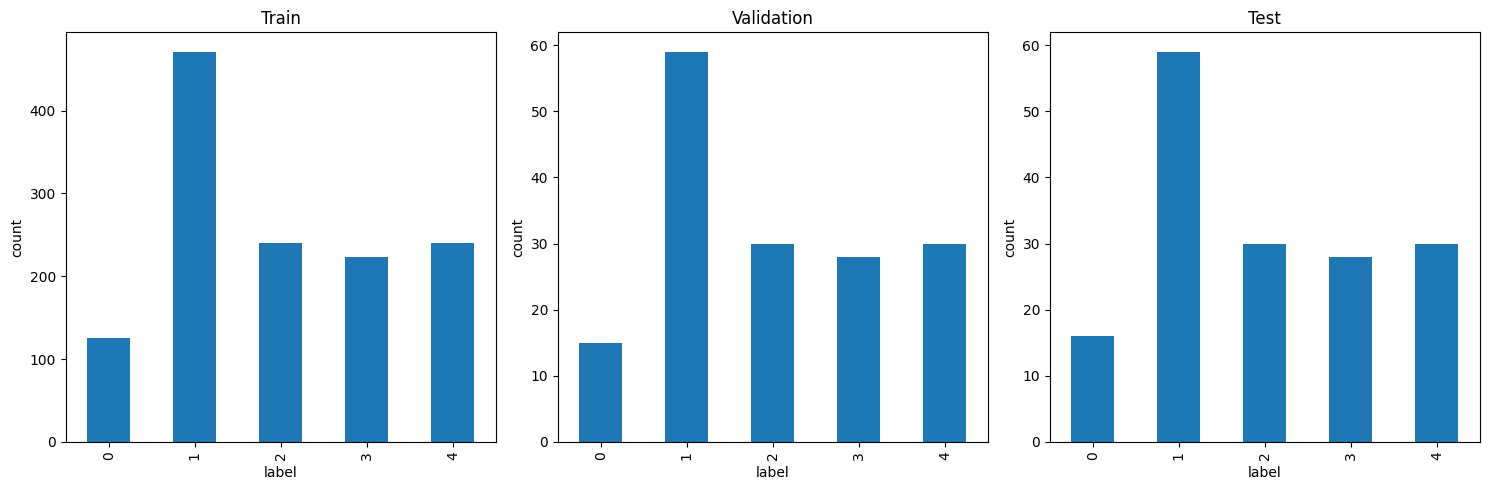

In [142]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [143]:
origin_df.iloc[:, -8:-1].describe()

,forehead,right_eye,left_eye,nasolabial,perioral,right_vol,left_vol
count,1624.000000,1624.000000,1624.000000,1624.000000,1624.000000,1624.000000,1624.000000
mean,0.748768,1.443350,1.448892,1.334360,1.212438,1.054187,1.019089
std,1.583086,1.023082,1.073330,1.306282,1.334806,1.208726,1.187947
min,-1.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000
25%,-1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [144]:
for col in origin_df.loc[:, 'forehead':'left_vol'].columns:
    print(f"[{col}] value_counts:")
    print(origin_df[col].value_counts().sort_index())

[forehead] value_counts:
forehead
-1    430
 0    478
 1    184
 2    257
 3    152
 4    123
Name: count, dtype: int64
[right_eye] value_counts:
right_eye
0    273
1    685
2    388
3    229
4     49
Name: count, dtype: int64
[left_eye] value_counts:
left_eye
-1      1
 0    321
 1    603
 2    403
 3    239
 4     57
Name: count, dtype: int64
[nasolabial] value_counts:
nasolabial
0    591
1    376
2    316
3    205
4    136
Name: count, dtype: int64
[perioral] value_counts:
perioral
-1      3
 0    703
 1    317
 2    293
 3    163
 4    145
Name: count, dtype: int64
[right_vol] value_counts:
right_vol
-1      2
 0    767
 1    299
 2    321
 3    167
 4     68
Name: count, dtype: int64
[left_vol] value_counts:
left_vol
0    780
1    322
2    294
3    167
4     61
Name: count, dtype: int64


In [145]:
len(train_df)

1299

In [146]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'right_eye_path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'right_eye_path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'right_eye_path'])

In [147]:
split_train.drop(columns=['label_x', 'label_y'], inplace=True)
split_val.drop(columns=['label_x', 'label_y'], inplace=True)
split_test.drop(columns=['label_x', 'label_y'], inplace=True)

In [148]:
split_train

,user_id,age,gender,forehead_path,right_eye_path,left_eye_path,nasolabial_path,perioral_path,right_vol_path,left_vol_path,forehead,right_eye,left_eye,nasolabial,perioral,right_vol,left_vol
76,0001,9,female,-1,030_data/data/right_eye_0001_face.jpg,030_data/data/left_eye_0001_face.jpg,030_data/data/nasolabial_0001_face.jpg,030_data/data/perioral_0001_face.jpg,030_data/data/right_vol_0001_face.jpg,030_data/data/left_vol_0001_face.jpg,-1,0,0,0,0,0,0
246,0003,16,female,-1,030_data/data/right_eye_0003_face.jpg,030_data/data/left_eye_0003_face.jpg,030_data/data/nasolabial_0003_face.jpg,030_data/data/perioral_0003_face.jpg,030_data/data/right_vol_0003_face.jpg,030_data/data/left_vol_0003_face.jpg,-1,1,0,0,0,0,0
31,0005,17,female,-1,030_data/data/right_eye_0005_face.jpg,030_data/data/left_eye_0005_face.jpg,030_data/data/nasolabial_0005_face.jpg,030_data/data/perioral_0005_face.jpg,030_data/data/right_vol_0005_face.jpg,030_data/data/left_vol_0005_face.jpg,-1,0,0,0,0,0,0
1195,0006,15,female,-1,030_data/data/right_eye_0006_face.jpg,030_data/data/left_eye_0006_face.jpg,030_data/data/nasolabial_0006_face.jpg,030_data/data/perioral_0006_face.jpg,030_data/data/right_vol_0006_face.jpg,030_data/data/left_vol_0006_face.jpg,-1,0,0,0,0,0,0
84,0007,18,female,-1,030_data/data/right_eye_0007_face.jpg,030_data/data/left_eye_0007_face.jpg,030_data/data/nasolabial_0007_face.jpg,030_data/data/perioral_0007_face.jpg,030_data/data/right_vol_0007_face.jpg,030_data/data/left_vol_0007_face.jpg,-1,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28,1972,77,female,030_data/data/forehead_1972_face.jpg,030_data/data/right_eye_1972_face.jpg,030_data/data/left_eye_1972_face.jpg,030_data/data/nasolabial_1972_face.jpg,030_data/data/perioral_1972_face.jpg,030_data/data/right_vol_1972_face.jpg,030_data/data/left_vol_1972_face.jpg,4,3,3,4,4,2,2
216,1973,75,female,030_data/data/forehead_1973_face.jpg,030_data/data/right_eye_1973_face.jpg,030_data/data/left_eye_1973_face.jpg,030_data/data/nasolabial_1973_face.jpg,030_data/data/perioral_1973_face.jpg,030_data/data/right_vol_1973_face.jpg,030_data/data/left_vol_1973_face.jpg,4,2,2,4,4,2,2
805,1976,69,female,030_data/data/forehead_1976_face.jpg,030_data/data/right_eye_1976_face.jpg,030_data/data/left_eye_1976_face.jpg,030_data/data/nasolabial_1976_face.jpg,030_data/data/perioral_1976_face.jpg,030_data/data/right_vol_1976_face.jpg,030_data/data/left_vol_1976_face.jpg,3,2,2,4,3,1,1
1160,1978,67,female,-1,030_data/data/right_eye_1978_face.jpg,030_data/data/left_eye_1978_face.jpg,030_data/data/nasolabial_1978_face.jpg,030_data/data/perioral_1978_face.jpg,030_data/data/right_vol_1978_face.jpg,030_data/data/left_vol_1978_face.jpg,-1,3,3,4,2,2,2


In [149]:
# user_id로 교집합을 구하여 중복된 user_id의 수를 확인

len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [150]:
with open(os.path.join(label_dir, 'wrinkle_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'wrinkle_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'wrinkle_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 028

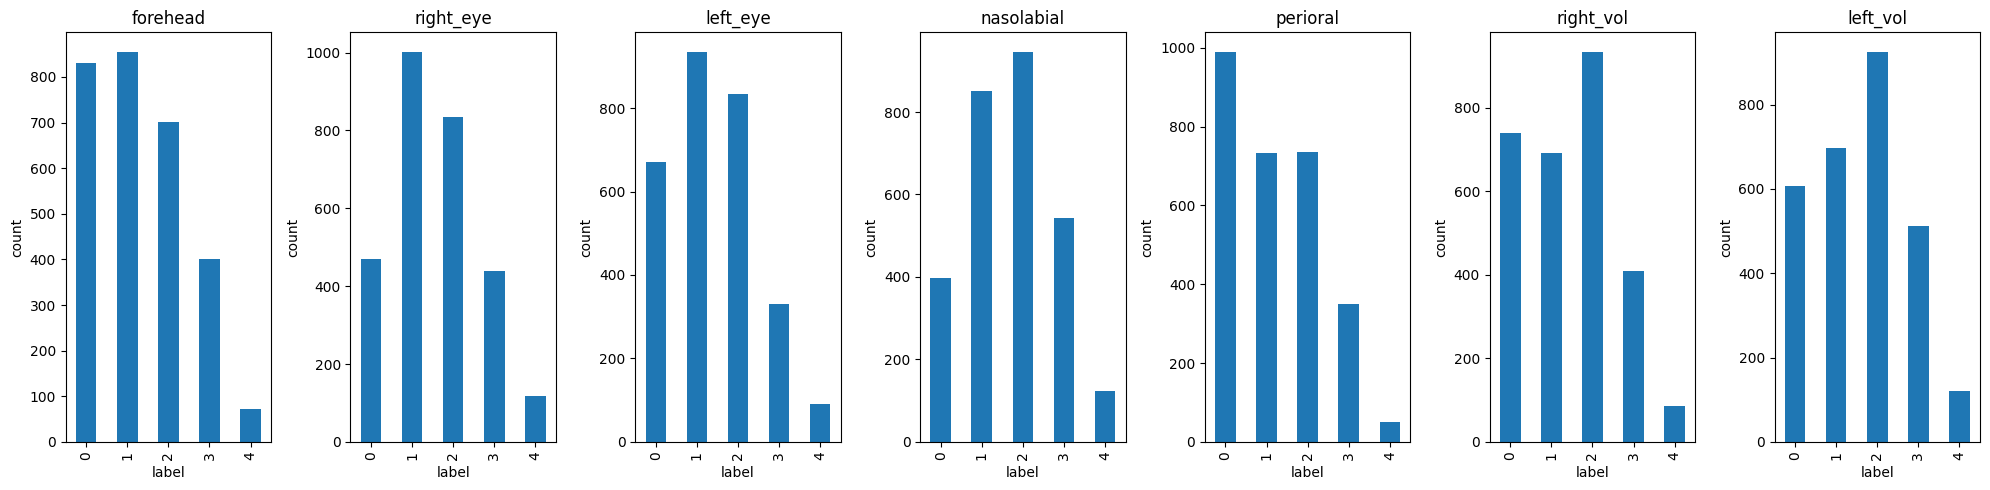

In [64]:
labels = {'forehead':[],'right_eye':[],'left_eye':[],'nasolabial':[],'perioral':[],'right_vol':[],'left_vol':[]}
origin_df.loc[:, 'forehead':]
for i, row in origin_df.loc[:, 'forehead':].iterrows():
    for col in labels.keys():
        labels[col].append(row[col])

fig, axes = plt.subplots(1, 7, figsize=(20, 5))
for i, (col, ax) in enumerate(zip(labels.keys(), axes)):
    pd.Series(labels[col]).value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('label')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

In [107]:
import os
import json
import pandas as pd
import random

label_dir = '/home/work/hocheol_dir/datasets/v0.2_data/wrinkle/028_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'wrinkle_label.json'), orient='records', dtype={'user_id':str, 'image_id':str})
origin_df['avg'] = origin_df.loc[:, 'forehead':].mean(axis=1).round()

user_dict = {}

for i, row in origin_df.iterrows():
    sum = 0
    num = 0
    lst = row.loc['forehead':].values.tolist()

    if max(lst) in [4]:
        label = max(lst)
    else:
        label = row['avg']
    
    if row['user_id'] not in user_dict:
        user_dict[row['user_id']] = label
    else:
        user_dict[row['user_id']] = max(user_dict[row['user_id']], label)

user_split = pd.DataFrame(list(user_dict.items()), columns=['user_id', 'label'])
user_split['label'].value_counts().sort_index()

label
0.0    113
1.0    361
2.0    315
3.0     50
4.0    126
Name: count, dtype: int64

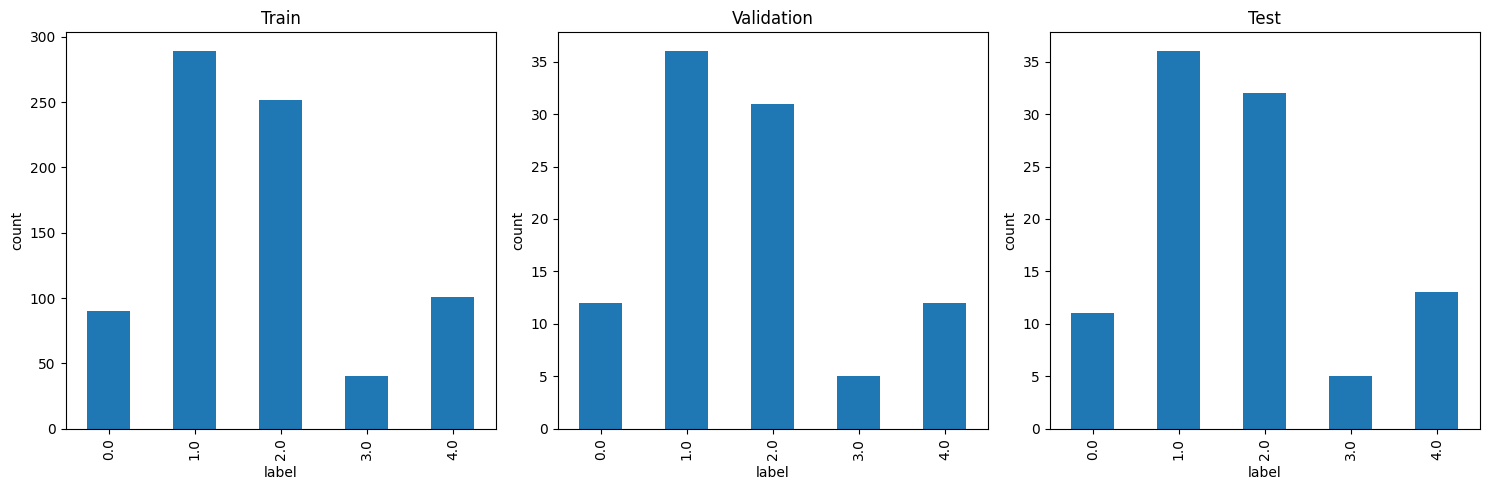

In [108]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [113]:
train_df['label'].describe()

count    772.000000
mean       1.705959
std        1.153719
min        0.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: label, dtype: float64

In [110]:
for col in origin_df.loc[:, 'forehead':'left_vol'].columns:
    print(f"[{col}] value_counts:")
    print(origin_df[col].value_counts().sort_index())

[forehead] value_counts:
forehead
0    831
1    855
2    702
3    400
4     72
Name: count, dtype: int64
[right_eye] value_counts:
right_eye
0     469
1    1002
2     834
3     438
4     117
Name: count, dtype: int64
[left_eye] value_counts:
left_eye
0    670
1    935
2    834
3    331
4     90
Name: count, dtype: int64
[nasolabial] value_counts:
nasolabial
0    397
1    852
2    946
3    542
4    123
Name: count, dtype: int64
[perioral] value_counts:
perioral
0    990
1    733
2    737
3    350
4     50
Name: count, dtype: int64
[right_vol] value_counts:
right_vol
0    740
1    691
2    934
3    408
4     87
Name: count, dtype: int64
[left_vol] value_counts:
left_vol
0    607
1    696
2    925
3    511
4    121
Name: count, dtype: int64


In [114]:
len(train_df), len(val_df), len(test_df)

(772, 96, 97)

In [122]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'right_eye_path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'right_eye_path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'right_eye_path'])

In [123]:
split_train.drop(columns=['avg', 'label'], inplace=True)
split_val.drop(columns=['avg', 'label'], inplace=True)
split_test.drop(columns=['avg', 'label'], inplace=True)

In [124]:
split_train

,user_id,image_id,forehead_path,right_eye_path,left_eye_path,nasolabial_path,perioral_path,right_vol_path,left_vol_path,forehead,right_eye,left_eye,nasolabial,perioral,right_vol,left_vol
958,0001,0001_01,028_data/data/forehead_0001_01_F.jpg.jpg,028_data/data/right_eye_0001_01_F.jpg.jpg,028_data/data/left_eye_0001_01_F.jpg.jpg,028_data/data/nasolabial_0001_01_F.jpg.jpg,028_data/data/perioral_0001_01_F.jpg.jpg,028_data/data/right_vol_0001_01_F.jpg.jpg,028_data/data/left_vol_0001_01_F.jpg.jpg,2,2,2,3,2,2,2
959,0001,0001_02,028_data/data/forehead_0001_02_F.jpg.jpg,028_data/data/right_eye_0001_02_F.jpg.jpg,028_data/data/left_eye_0001_02_F.jpg.jpg,028_data/data/nasolabial_0001_02_F.jpg.jpg,028_data/data/perioral_0001_02_F.jpg.jpg,028_data/data/right_vol_0001_02_F.jpg.jpg,028_data/data/left_vol_0001_02_F.jpg.jpg,2,2,2,3,2,1,1
960,0001,0001_03,028_data/data/forehead_0001_03_F.jpg.jpg,028_data/data/right_eye_0001_03_F.jpg.jpg,028_data/data/left_eye_0001_03_F.jpg.jpg,028_data/data/nasolabial_0001_03_F.jpg.jpg,028_data/data/perioral_0001_03_F.jpg.jpg,028_data/data/right_vol_0001_03_F.jpg.jpg,028_data/data/left_vol_0001_03_F.jpg.jpg,3,2,2,3,2,2,2
27,0002,0002_01,028_data/data/forehead_0002_01_F.jpg.jpg,028_data/data/right_eye_0002_01_F.jpg.jpg,028_data/data/left_eye_0002_01_F.jpg.jpg,028_data/data/nasolabial_0002_01_F.jpg.jpg,028_data/data/perioral_0002_01_F.jpg.jpg,028_data/data/right_vol_0002_01_F.jpg.jpg,028_data/data/left_vol_0002_01_F.jpg.jpg,2,2,3,2,2,2,2
28,0002,0002_02,028_data/data/forehead_0002_02_F.jpg.jpg,028_data/data/right_eye_0002_02_F.jpg.jpg,028_data/data/left_eye_0002_02_F.jpg.jpg,028_data/data/nasolabial_0002_02_F.jpg.jpg,028_data/data/perioral_0002_02_F.jpg.jpg,028_data/data/right_vol_0002_02_F.jpg.jpg,028_data/data/left_vol_0002_02_F.jpg.jpg,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,1099,1099_02,028_data/data/forehead_1099_02_F.jpg.jpg,028_data/data/right_eye_1099_02_F.jpg.jpg,028_data/data/left_eye_1099_02_F.jpg.jpg,028_data/data/nasolabial_1099_02_F.jpg.jpg,028_data/data/perioral_1099_02_F.jpg.jpg,028_data/data/right_vol_1099_02_F.jpg.jpg,028_data/data/left_vol_1099_02_F.jpg.jpg,1,0,0,0,0,1,1
894,1099,1099_03,028_data/data/forehead_1099_03_F.jpg.jpg,028_data/data/right_eye_1099_03_F.jpg.jpg,028_data/data/left_eye_1099_03_F.jpg.jpg,028_data/data/nasolabial_1099_03_F.jpg.jpg,028_data/data/perioral_1099_03_F.jpg.jpg,028_data/data/right_vol_1099_03_F.jpg.jpg,028_data/data/left_vol_1099_03_F.jpg.jpg,1,0,0,0,0,1,1
1422,1100,1100_01,028_data/data/forehead_1100_01_F.jpg.jpg,028_data/data/right_eye_1100_01_F.jpg.jpg,028_data/data/left_eye_1100_01_F.jpg.jpg,028_data/data/nasolabial_1100_01_F.jpg.jpg,028_data/data/perioral_1100_01_F.jpg.jpg,028_data/data/right_vol_1100_01_F.jpg.jpg,028_data/data/left_vol_1100_01_F.jpg.jpg,1,1,1,1,0,1,1
1423,1100,1100_02,028_data/data/forehead_1100_02_F.jpg.jpg,028_data/data/right_eye_1100_02_F.jpg.jpg,028_data/data/left_eye_1100_02_F.jpg.jpg,028_data/data/nasolabial_1100_02_F.jpg.jpg,028_data/data/perioral_1100_02_F.jpg.jpg,028_data/data/right_vol_1100_02_F.jpg.jpg,028_data/data/left_vol_1100_02_F.jpg.jpg,1,1,0,1,0,1,1


In [126]:
# user_id로 교집합을 구하여 중복된 user_id의 수를 확인

len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [127]:
with open(os.path.join(label_dir, 'wrinkle_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'wrinkle_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'wrinkle_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)